In [438]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

In [439]:
# Dummy Dataset for our model
df = pd.DataFrame(
    {
        'x1' :  [5,2,1,9,3],
        'x2' :  [7,9,3,8,7],
        'y'  :  [1,0,1,0,0]
    }   
)

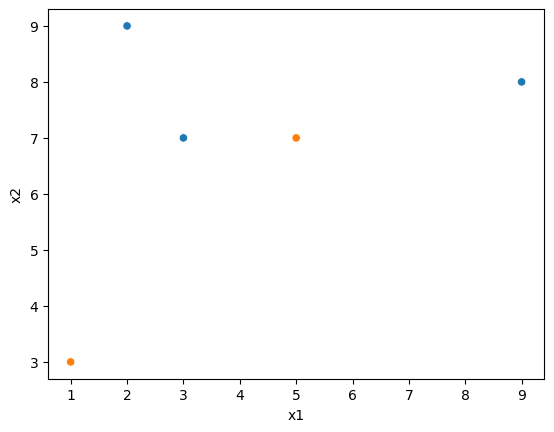

In [440]:
sns.scatterplot(    
                    data = df,
                    x = 'x1' , 
                    y = 'x2',
                    hue = 'y',
                    legend = False
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [441]:
df

,x1,x2,y
0,5,7,1
1,2,9,0
2,1,3,1
3,9,8,0
4,3,7,0


In [442]:
# Weights = 1/len(df) or No of rows
df['weights'] = 1/len(df)

In [443]:
df

,x1,x2,y,weights
0,5,7,1,0.2
1,2,9,0,0.2
2,1,3,1,0.2
3,9,8,0,0.2
4,3,7,0,0.2


In [444]:
X , y  =  df.iloc[:,:2].values , df.iloc[:,-2].values

In [445]:
# Now I will create a weak learner Decision Tree model with max_depth = 1 that willm act as a stump.

dtr1 = DecisionTreeClassifier(max_depth=1)

In [446]:
dtr1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [447]:
df['y_pred'] = dtr1.predict(X)

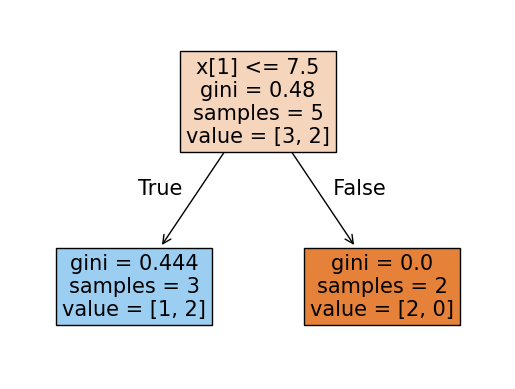

In [448]:
plot_tree(
            dtr1 ,
            filled = True,
            fontsize = 15
        )
plt.show()

In [449]:
df

,x1,x2,y,weights,y_pred
0,5,7,1,0.2,1
1,2,9,0,0.2,0
2,1,3,1,0.2,1
3,9,8,0,0.2,0
4,3,7,0,0.2,1


In [450]:
# Missclassifed points :  (3,7)
# Model Weight : alpha1 = 0.5*ln*(1-sum_of_error_weights)/(sum_of_error_weights) 
eta = 1e-10 # To avoid alpha from getting zero when the model fully classified
alpha1 = 0.5*np.log((1-(0.2+eta))/(0.2+eta)) # 0.2 is the weight of misclassifed point (3,7)

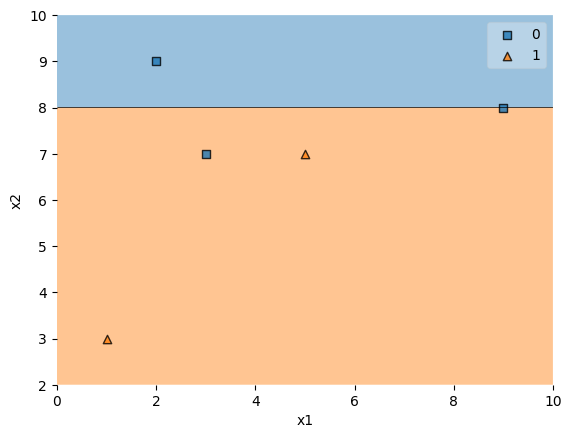

In [451]:
plot_decision_regions(  
                        X,
                        y,
                        dtr1)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [452]:
# Now as we can see the point (3,7) is misclassified so We need on upsample it and send forward to our next model.
# To upsample we have this formula for the correct classified points and incorrectly classified points
# new_weight_correctly_classified = current_weight*(e**(alpha))
# new_weight_incorrectly_classified = current_weight*(e**(-alpha))

In [453]:
df['updated_weights'] = np.where(
                                    df['y'] == df['y_pred'] ,  # The condition
                                    df['weights']*(np.e**(-alpha1)), # The statement executed when the condition is true
                                    df['weights']*(np.e**(alpha1))  # The statement executed when the condition is false
)

In [454]:
df

,x1,x2,y,weights,y_pred,updated_weights
0,5,7,1,0.2,1,0.1
1,2,9,0,0.2,0,0.1
2,1,3,1,0.2,1,0.1
3,9,8,0,0.2,0,0.1
4,3,7,0,0.2,1,0.4


In [455]:
# Now we will normalize these new_weights
# normalized_weights = updated_weights/sum(updated_weights)
# Why Normalized ? We want the weights to follow a normal distribution between range 0 and 1.
# We will use this range for further creation of range and random values 

In [456]:
df['normalized_weights'] = df['updated_weights']/np.sum(df['updated_weights'])

In [457]:
df

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights
0,5,7,1,0.2,1,0.1,0.125
1,2,9,0,0.2,0,0.1,0.125
2,1,3,1,0.2,1,0.1,0.125
3,9,8,0,0.2,0,0.1,0.125
4,3,7,0,0.2,1,0.4,0.500


In [458]:
# Now we will create a range of values where the range_start of i = range_end of i-1 
# and range end of i = range_start + normalized_weight for that i. (for i = 1 range_start = 0.000 and range_end = 1.000)
# Basically the cumilative sum of normalized_weights.
# We will use the cumulitive sum method of numpy for this and the range will be : 0 ~ 1

In [459]:
df['range_end'] = np.cumsum(df['normalized_weights'])
df['range_start'] = df['range_end'] - df['normalized_weights']

In [460]:
df

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights,range_end,range_start
0,5,7,1,0.2,1,0.1,0.125,0.125,0.000
1,2,9,0,0.2,0,0.1,0.125,0.250,0.125
2,1,3,1,0.2,1,0.1,0.125,0.375,0.250
3,9,8,0,0.2,0,0.1,0.125,0.500,0.375
4,3,7,0,0.2,1,0.4,0.500,1.000,0.500


In [461]:
# Now will create random values in the range 0 ~ 1( as the weights are normalized now), and then we will place these 
# values in the each range .

# Basically this is a funtion which will return the indices of the points which are to be taken as input for new model.
# Occurance of the indices is proportional to misclassifed points , basically when we do this step there will be more misclassified point
# passed and this will lead to the next model knowing that these points were misclassified .

# Now the new points with repeated misclassified points will be taken as input .

def create_new_dataset(df):
  indices = []
  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['range_end'] > a and a > row['range_start']:
        indices.append(index)
  return indices

In [462]:
index_for_new_dataframe = create_new_dataset(df)

In [463]:
index_for_new_dataframe # As you can clearly see the index 4 which was misclassified was upsampled.

[4, 2, 4, 1, 4]

In [464]:
df1 = df.iloc[index_for_new_dataframe,[0,1,2,3]]

In [465]:
df1

,x1,x2,y,weights
4,3,7,0,0.2
2,1,3,1,0.2
4,3,7,0,0.2
1,2,9,0,0.2
4,3,7,0,0.2


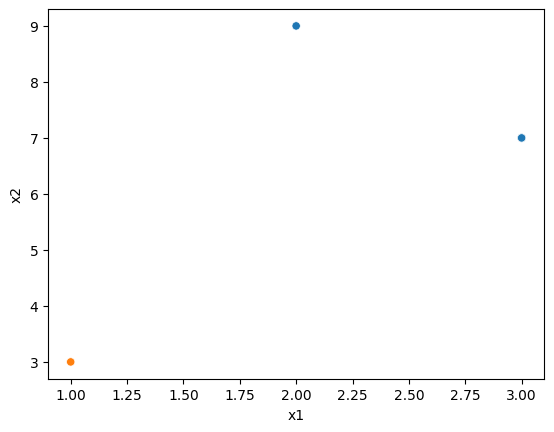

In [466]:
sns.scatterplot(
                    data = df1,
                    x = 'x1' ,
                    y = 'x2' ,
                    hue = 'y',
                    legend = False
)
plt.show()

In [467]:
# Now I will repeat all the steps again but with new Decision tree which will be again a weak learner 

In [468]:
X1 , y1  =  df1.iloc[:,:2].values , df1.iloc[:,-2].values

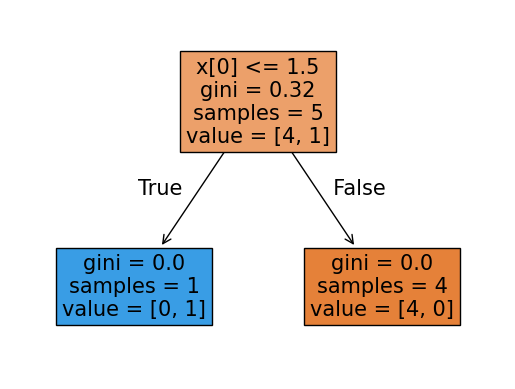

In [469]:
dtr2 = DecisionTreeClassifier(max_depth=1)
dtr2.fit(X1,y1)
df1['y_pred'] = dtr2.predict(X1)
plot_tree(
            dtr2 ,
            filled = True,
            fontsize = 15
        )
plt.show()

In [470]:
df1

,x1,x2,y,weights,y_pred
4,3,7,0,0.2,0
2,1,3,1,0.2,1
4,3,7,0,0.2,0
1,2,9,0,0.2,0
4,3,7,0,0.2,0


In [471]:
alpha2 = 0.5*np.log((1-eta+0)/(0+eta))

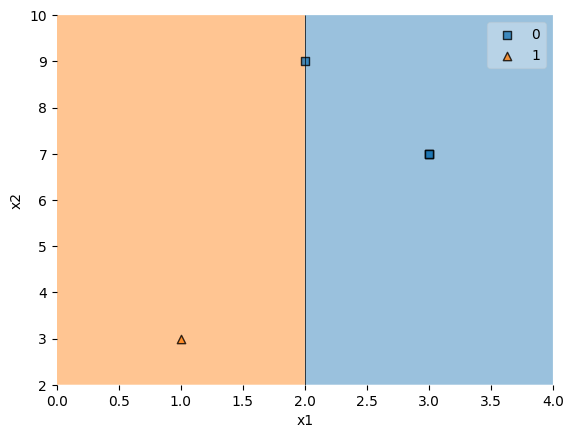

In [472]:
plot_decision_regions(  
                        X1,
                        y1,
                        dtr2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [473]:
# Below step is just for convergence condition , If for example any other value is added and that is misclassified by 
# the current decision tree than further looping will be done till there are any errors left .

In [474]:
df1['updated_weights'] = np.where(
                                    df1['y'] == df1['y_pred'] ,  # The condition
                                    df1['weights']*(np.e**(-alpha2)), # The statement executed when the condition is true
                                    df1['weights']*(np.e**(alpha2))  # The statement executed when the condition is false
)
df1['normalized_weights'] = df1['updated_weights']/np.sum(df1['updated_weights'])

In [475]:
df1

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights
4,3,7,0,0.2,0,0.000002,0.2
2,1,3,1,0.2,1,0.000002,0.2
4,3,7,0,0.2,0,0.000002,0.2
1,2,9,0,0.2,0,0.000002,0.2
4,3,7,0,0.2,0,0.000002,0.2


In [476]:
df1['range_end'] = np.cumsum(df1['normalized_weights'])
df1['range_start'] = df1['range_end'] - df1['normalized_weights']
df1

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights,range_end,range_start
4,3,7,0,0.2,0,0.000002,0.2,0.2,0.0
2,1,3,1,0.2,1,0.000002,0.2,0.4,0.2
4,3,7,0,0.2,0,0.000002,0.2,0.6,0.4
1,2,9,0,0.2,0,0.000002,0.2,0.8,0.6
4,3,7,0,0.2,0,0.000002,0.2,1.0,0.8


In [477]:
index_for_new_dataframe = create_new_dataset(df1)
index_for_new_dataframe 

[4, 1, 4, 4, 4]

In [478]:
df2 = df1.iloc[index_for_new_dataframe,[0,1,2,3]]
df2

,x1,x2,y,weights
4,3,7,0,0.2
2,1,3,1,0.2
4,3,7,0,0.2
4,3,7,0,0.2
4,3,7,0,0.2


In [479]:
# The dataset we used was very simple but this is the basic implementation of AdaboostClassifier works

In [480]:
# Now for suppose if there is any point lets say : 3,7 then the output will be calcuated as :
# y_pred_data_points = alpha1*dtr1.predict(new_point) * alpha2*dtr2.predict(new_point) .... alphan*dtrn.predict(new_point)

In [481]:
# 1. Create New test points.
new_points = pd.DataFrame(  {
                                'x1' : [3,2,4],
                                'x2' : [7,3,9]
}    ).values

In [482]:
# 2. Get votes for each tree ; 1 if dtr1.predict(new_points) == 1 else -1 (FAILS for multiple points)
vote1 = np.where(dtr1.predict(new_points) == 1, 1, -1)
vote2 = np.where(dtr2.predict(new_points) == 1, 1, -1)

In [483]:
# 3. Calculate Weighted Sum (Addition, not Multiplication!)
sum_of_votes = (alpha1 * vote1) + (alpha2 * vote2)

In [484]:
# 4. Final Classification (Threshold at 0)
final_prediction = np.where(
                                sum_of_votes > 0,
                                1,
                                0
)

In [485]:
final_prediction # The predicted label is 0

array([0, 0, 0])

In [486]:
# Now to cross verify we will run this with AdaBoostClassifer model.

In [498]:
from sklearn.ensemble import AdaBoostClassifier

In [499]:
adbc = AdaBoostClassifier(  
                            # estimator = DecisionTreeClassifier(max_depth=1),
                            # algorithm='SAMME', # Deprecated
                            n_estimators = 3
)

In [500]:
adbc.fit(X,y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",3
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [501]:
y_pred_new_point_adbc = adbc.predict(new_points)

In [502]:
y_pred_new_point_adbc

array([0, 0, 0])

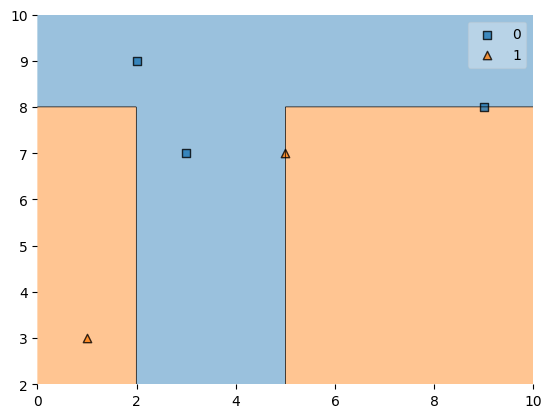

In [503]:
plot_decision_regions(
                        X,
                        y,
                        adbc
)
plt.show()